# 08 — Event or fault? Diagnosing the flagged sensors

NB05 ranks sensors by how often they agree with the rest of the network, and
NB07 fits each sensor's offset and gain against the network under uniform
conditions. Both produce candidates for a site visit. Neither says *why* a
sensor disagrees, and on the leading case the two disagree with each other:
SL051 has the lowest lifetime CSI in the network and, on the NB07 regression,
no measurable offset and a gain of 0.99.

That matters beyond one sensor. A low CSI has two quite different causes. The
instrument may be wrong — a drifting zero, a calibration slope, a frozen
channel. Or the air at that site may genuinely differ from the rest of the
network, which is what a sensor network is for. The first calls for an
engineer; the second calls for a report to the Council. Byrne et al. (2024,
Sect. 2.1.1) avoid the ambiguity by harmonising every sensor onto a common
reference from co-location data before computing the CSI, so that what remains
is air rather than instrument. No Leeds sensor has been co-located, so the
separation has to be made after the fact.

This notebook makes it in four steps, each answering a question the previous
one leaves open:

1. **Is it calibration?** Harmonise every sensor using the NB07 fit and
   recompute the CSI. Disagreement that vanishes was instrumental.
2. **How large a fault would it take?** Inject known faults into healthy Leeds
   series and read off the CSI they produce, so an observed score can be
   converted into a fault size.
3. **Is the residual disagreement organised like a source?** Byrne et al.
   (2023) mark hours dominated by nearby combustion using the standard
   deviation of the two-minute readings within the hour. A domestic solid-fuel
   source is concentrated in winter evenings; a noisy instrument is not.
4. **What does the fluctuation look like up close?** A plume takes minutes to
   arrive and clear, so consecutive two-minute readings are strongly related,
   and it registers on both Plantower counters at once. Electronic noise does
   neither.

Steps 1 and 3 use data the earlier notebooks deliberately look past. Step 1
uses the well-mixed-hour fit; step 3 is the first use anywhere in this project
of the two-minute resolution that makes the Leeds archive unusual.

### How this notebook is structured

Restructured to separate two genuinely different operational questions --
is a sensor sending data at all, and does its data look unusual -- per
supervisor review. Section numbers below match the headers used throughout:

- **Purpose** -- above. **Loading the data** -- next cell, unchanged.
- **Part 2 -- Current sensor availability**: is each sensor sending data at
  all, right now? Checked against the real gap in each sensor's own record.
- **Part 3 -- Analysis of currently reporting sensors**: a quick check of
  the relevant NB07 numbers, then the four-step diagnosis and verdict rule
  -- unchanged, validated earlier work.
- **Part 4 -- Local concentration/event analysis**: does an unusual reading
  show up at nearby sensors too (regional/shared) or only at the one site?
- **Part 5 -- van Zoest et al. (2018), adapted**: an independent,
  observation-level outlier test, at both daily and evening-hour resolution.
- **Part 6 -- Combine evidence from previous notebooks**: one real table
  joining CSI, bias, verdict, availability, both van Zoest rates, and a
  simple multivariate check (Isolation Forest) for every candidate.
- **Part 7 -- Operational interpretation**: every sensor sorted into the
  categories the project's actual aim needs -- offline, no evidence, worth
  investigating, or a possible local event.
- **Part 8 -- Final conclusion**, and a **final summary table** covering
  every sensor in the study.

In [2]:
import re
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
from src.baseline import (loo_baseline, local_increment, harmonise,
                          nearest_neighbours)
from src.csi import csi_matrix, sensor_ranking
from src.highfreq import (hourly_stats, flag_local_hours, exposure_fractions,
                          seasonal_fractions, diurnal_sigma,
                          excursion_structure)
from src.synthetic import csi_response
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def short_code(name):
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)


# Daily means from NB05, on short codes throughout this notebook.
daily = pd.read_parquet(DAILY_MATRIX)
daily.columns = [short_code(c) for c in daily.columns]

# Where each sensor's two-minute record lives, for step 3.
paths = {short_code(p.stem): p for p in sorted(CLEANED.glob("*.parquet"))}

rank = pd.read_csv(Tables / "csi_sensor_ranking.csv", index_col=0)
rank.index = [short_code(i) for i in rank.index]

bias = pd.read_csv(Tables / "instrument_bias.csv", index_col=0)
bias.index = [short_code(i) for i in bias.index]

flags = pd.read_csv(Tables / "cleaning_summary.csv")
flags.index = [short_code(s) for s in flags["sensor"]]

sensors = pd.read_csv(Tables / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]

print(f"daily matrix: {daily.shape[0]} days x {daily.shape[1]} sensors")
print(f"two-minute records available for {len(paths)} sensors")
print(f"NB07 fitted a bias for {bias['gain'].notna().sum()} sensors")

daily matrix: 1616 days x 43 sensors
two-minute records available for 47 sensors
NB07 fitted a bias for 46 sensors


## Part 2 — Current sensor availability

Before asking whether a sensor's *readings* look unusual, a simpler question
needs answering first: is it sending data at all right now? A sensor that has
stopped reporting is an operational problem on its own, and there is no
"current behaviour" to test for one that has gone silent -- it needs an
operational look, not a statistical one.

**The rule, and how it was chosen.** For every sensor, find the most recent
day it produced any reading, and measure how far behind the end of the study
period that is. The table below prints that gap for every sensor so the
cutoff isn't picked blind. A sensor still reporting has a gap of a day or two
(the last day or so can lag while syncing). A full week -- 7 days -- with
nothing at all is a plain, easily-defended operational trigger: whatever the
cause, that sensor needs attention regardless of anything else in this
notebook. This is checked against the real distribution below rather than
assumed; if the data don't show any sensor going quiet, that's reported as a
genuine (and reassuring) finding, not forced into two groups that don't exist.

In [3]:
# Last reading date per sensor, straight from the cleaned 2-minute files --
# this checks whether data is arriving at all, before anything about its
# quality is considered.
last_seen = {}
for code, p in paths.items():
    d = pd.read_parquet(p, columns=[DATE_COL])
    last_seen[code] = pd.to_datetime(d[DATE_COL], utc=True).max()
last_seen = pd.Series(last_seen, name="last_reading")

study_end = daily.index.max()
gap_days = (study_end - last_seen).dt.days.sort_values()
# A sensor still transmitting can show a small NEGATIVE gap here: `daily` is
# built from full days with enough readings to average (NB05), while a
# sensor's very last day of raw 2-minute readings may not yet have enough
# for that -- so its last raw reading can sit a day after the daily
# matrix's own last complete day. That's a sign of being fully current, not
# an error, so it's floored at 0 for the printed table below.
gap_days = gap_days.clip(lower=0)

print(f"study period ends: {study_end.date()}\n")
print("days since each sensor's last reading, all sensors, sorted:\n")
print(gap_days.to_string())

OFFLINE_GAP_DAYS = 7   # a full week with nothing at all -- see markdown above
not_reporting = gap_days[gap_days >= OFFLINE_GAP_DAYS].index.tolist()
currently_reporting = gap_days[gap_days < OFFLINE_GAP_DAYS].index.tolist()

print(f"\ncurrently reporting: {len(currently_reporting)} sensors")
print(f"not currently reporting (gap >= {OFFLINE_GAP_DAYS} days): "
     f"{len(not_reporting)} sensors")
if not_reporting:
    print(f"  {not_reporting}")
else:
    print("  none -- every sensor with a two-minute record has reported "
         f"within the last {OFFLINE_GAP_DAYS} days")

study period ends: 2026-08-10

days since each sensor's last reading, all sensors, sorted:

SL006       0
SL007       0
SL011       0
SL016       0
SL020       0
SL026       0
SL025       0
SL024       0
SL027       0
SL037       0
SL050       0
SL062       0
SL056       0
SL051       0
SL042       0
SL021       1
SL034       2
SL008      34
SL022      52
SL012     118
SL044     124
SL040     145
SL001     171
SL005     184
SL018     195
SL019     200
SL035     271
SL038     328
SL017     360
SL033     402
SL045     415
SL060     454
SL003     533
SL055     538
SL041     586
SL009     780
SL015     792
SL054     794
SL032     809
SL036     877
SL023     923
SL028     942
SL029     957
SL068    1007
SL031    1175
SL030    1219
SL057    1258

currently reporting: 17 sensors
not currently reporting (gap >= 7 days): 30 sensors
  ['SL008', 'SL022', 'SL012', 'SL044', 'SL040', 'SL001', 'SL005', 'SL018', 'SL019', 'SL035', 'SL038', 'SL017', 'SL033', 'SL045', 'SL060', 'SL003', 'SL055', 'SL041', 

### When did each sensor stop, not just how long ago

The chart above answers "how long since this sensor last reported" but not
"was it always like this, or did something change at a particular point."
The wider SEE AQ Projects team's own `Data_Coverage.R` script (J. Levine)
does something related for exactly this reason -- a calendar-style heatmap
of daily coverage per sensor, run automatically to spot downtime patterns.
Adapted here as monthly coverage instead of a weekday/week grid, which suits
a 4.5-year, 47-sensor study better than a single month's calendar would.

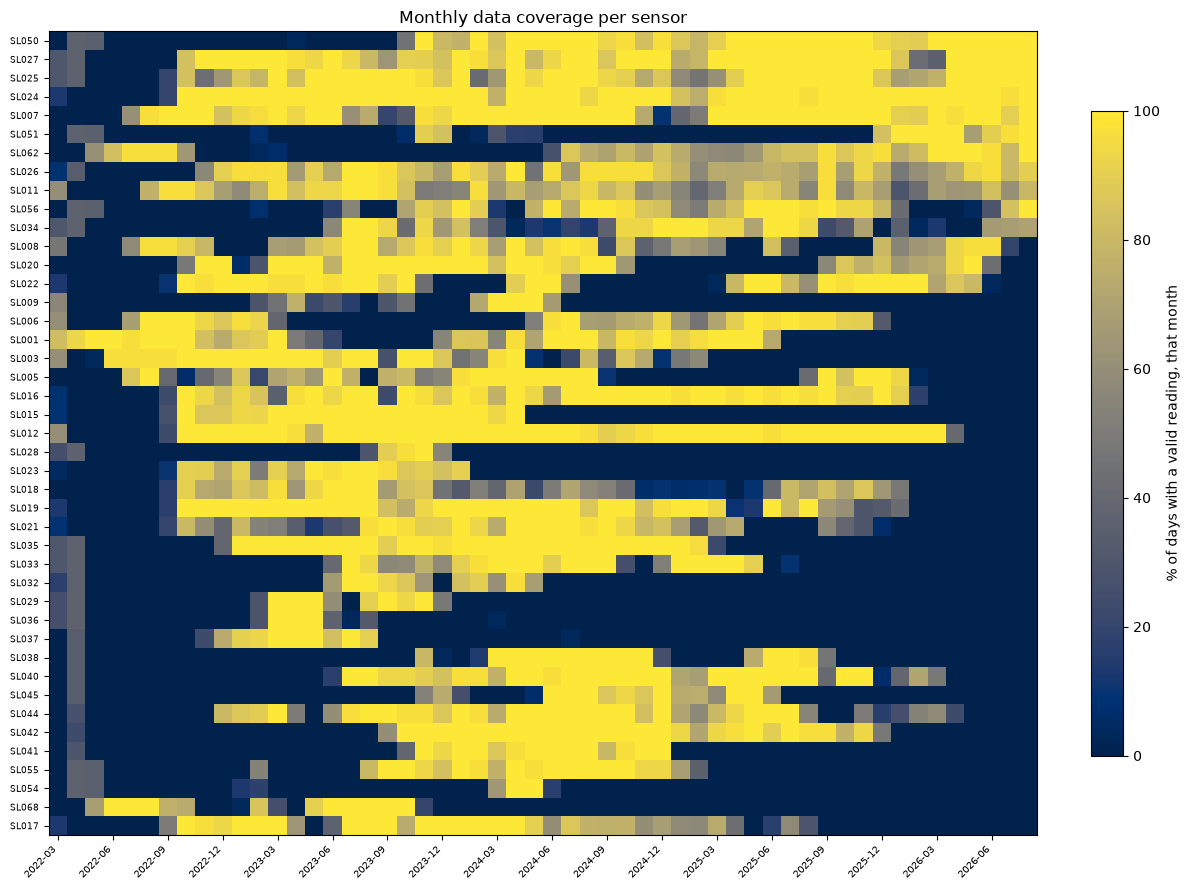

In [ ]:

# with a valid reading -- adapted to a sensor x month grid rather than a
# weekday/week calendar, and reusing `daily` (already loaded) rather than
# re-reading raw files per day.
monthly_coverage = daily.notna().resample("MS").mean().T * 100

# sort so currently-active sensors group together and the drop-off pattern
# is easy to read, rather than alphabetical
recent_cols = monthly_coverage.columns[-3:]
order = monthly_coverage[recent_cols].mean(axis=1).sort_values(ascending=False).index
monthly_coverage = monthly_coverage.loc[order]

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(monthly_coverage.values, aspect="auto", cmap="cividis", vmin=0, vmax=100)
ax.set_yticks(range(len(monthly_coverage)))
ax.set_yticklabels(monthly_coverage.index, fontsize=6.5)
step = 3
ax.set_xticks(range(0, monthly_coverage.shape[1], step))
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_coverage.columns[::step]],
                   rotation=45, ha="right", fontsize=7)
fig.colorbar(im, ax=ax, label="% of days with a valid reading, that month", fraction=0.03)
ax.set_title("Monthly data coverage per sensor")
fig.tight_layout()
fig.savefig(Figures / "08_monthly_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 3 — Analysis of currently reporting sensors

First, a quick, direct check of the specific NB07 numbers this notebook leans on hardest (the SL050/SL051 contrast), read from the tables already loaded -- nothing recomputed. Then the full four-step diagnosis and verdict rule below.

In [5]:
# Read straight from the tables NB05/NB07 already produced -- nothing
# recomputed here.
print("Lifetime CSI, worst 6 sensors:")
print(rank.sort_values("mean_csi").head(6)[["mean_csi"]].to_string())

print("\nNB07 fitted bias, largest |bias| first:")
print(bias.reindex(bias["bias_ref"].abs().sort_values(ascending=False).index)
     .head(6)[["offset_ugm3", "gain", "bias_ref"]].round(2).to_string())

print("\nThe SL050 / SL051 contrast this notebook exists to resolve:")
for c in ["SL050", "SL051"]:
    if c in rank.index and c in bias.index:
        print(f"  {c}: CSI = {rank.loc[c, 'mean_csi']:.3f}, "
              f"offset = {bias.loc[c, 'offset_ugm3']:+.2f} ug/m3, "
              f"gain = {bias.loc[c, 'gain']:.2f}")
print("\nBoth score badly on CSI. Only one of them has a calibration fit "
      "that looks wrong -- which is the ambiguity Part 4 is built to resolve.")

Lifetime CSI, worst 6 sensors:
       mean_csi
SL051     0.316
SL050     0.320
SL006     0.460
SL018     0.536
SL022     0.582
SL028     0.583

NB07 fitted bias, largest |bias| first:
       offset_ugm3  gain  bias_ref
SL050        -1.89  0.95     -2.71
SL051         0.42  0.83     -2.12
SL045         0.18  0.85     -2.06
SL019         0.26  1.10      1.78
SL015         0.35  1.09      1.71
SL018        -0.46  1.14      1.68

The SL050 / SL051 contrast this notebook exists to resolve:
  SL050: CSI = 0.320, offset = -1.89 ug/m3, gain = 0.95
  SL051: CSI = 0.316, offset = +0.42 ug/m3, gain = 0.83

Both score badly on CSI. Only one of them has a calibration fit that looks wrong -- which is the ambiguity Part 4 is built to resolve.


### The four-step diagnosis

Internal headings below ("1 Which sensors..." through "6 Verdicts") are this part's own structure, unchanged from validated earlier work.

## 1  Which sensors need a verdict

Three well-behaved sensors are chosen first, as a reference group: the
best-scoring sensors that also have a long record, so the contrast is not with
a sensor that simply has little data. They are removed from consideration for
the candidate set below -- a sensor cannot be both the standard other sensors
are judged against and one of the sensors being judged.

A remaining sensor earns a verdict if any of the detectors built so far points
at it: a low lifetime CSI, a large fitted bias, a high rate of frozen readings,
or a high rate of A/B disagreement. They are kept as separate entry routes
rather than combined into a score, because they are not commensurable, and
because a sensor caught by only one of them is exactly the interesting case.

The A/B entry route is deliberately loose (`AB_FLAG_LEVEL = 50%`) and is not
by itself evidence of anything: NB04's own ranking shows the network-wide
high-band rate runs from about 30% to 98% with a mean of 68%, so at Leeds
concentrations even a healthy PA-II fails Byrne's +/-5% test on Poisson noise
alone. Entry only decides who gets looked at; the verdict rule in Section 6
uses a much stricter, separately-justified bar (`AB_VERDICT_LEVEL = 90%`) for
this route, precisely so that "candidate" does not end up meaning "member of
the network".

Bias is compared at a common concentration — `bias_ref`, the fitted error at
15 µg/m³ — rather than at `bias_max`, which is evaluated over each sensor's own
fitted range and so is not comparable between sensors.

In [6]:
# Reference group first: best-scoring sensors that also have a long record,
# so the contrast is not with a sensor that simply has little data. Computed
# before the candidate set so the two can never overlap -- a sensor cannot be
# simultaneously the standard other sensors are judged against and one of the
# sensors being judged.
long_lived = daily.notna().sum()
eligible = rank.index[(rank["mean_csi"] > 0.75)
                      & (rank.index.isin(long_lived[long_lived > 500].index))]
references = rank.loc[eligible, "mean_csi"].nlargest(3).index.tolist()

low_csi   = rank.index[rank["mean_csi"] <= CSI_FLAG_LEVEL].tolist()
worst_csi = rank.nsmallest(CSI_FLAG_N, "mean_csi").index.tolist()
biased    = bias.index[bias["bias_ref"].abs() > VERDICT_BIAS_MIN].tolist()
frozen    = flags.index[flags["pct_flatline"] > VERDICT_FLATLINE].tolist()
ab_heavy  = flags.index[flags["pct_ab_highband"] > AB_FLAG_LEVEL].tolist()

candidates = sorted(set(low_csi) | set(worst_csi) | set(biased)
                    | set(frozen) | set(ab_heavy))
candidates = [c for c in candidates if c in daily.columns and c not in references]

why = pd.DataFrame({
    "mean_csi":     rank["mean_csi"].reindex(candidates).round(3),
    "bias_ref":     bias["bias_ref"].reindex(candidates).round(2),
    "pct_ab_high":  flags["pct_ab_highband"].reindex(candidates),
    "pct_flatline": flags["pct_flatline"].reindex(candidates),
    "valid_days":   daily.notna().sum().reindex(candidates),
    "mean_daily":   daily.mean().reindex(candidates).round(2),
})
why["flagged_by"] = [
    ", ".join(t for t, s in [("CSI", low_csi + worst_csi), ("bias", biased),
                             ("frozen", frozen), ("A/B", ab_heavy)] if c in s)
    for c in candidates]

print(f"candidates: {len(candidates)}   reference group: {references}\n")
print(why.sort_values("mean_csi").to_string())

candidates: 35   reference group: ['SL007', 'SL025', 'SL020']

       mean_csi  bias_ref  pct_ab_high  pct_flatline  valid_days  mean_daily      flagged_by
SL051     0.316     -2.12         37.2           0.0         333        7.28       CSI, bias
SL050     0.320     -2.71         60.1           0.0        1003        2.24  CSI, bias, A/B
SL006     0.460      0.55         79.0           0.0         739        2.19        CSI, A/B
SL018     0.536      1.68         97.9           0.0         714        1.60  CSI, bias, A/B
SL022     0.582     -0.92         48.2           0.0         899        3.35             CSI
SL028     0.583     -0.81         78.6           0.0         130        2.59        CSI, A/B
SL003     0.587      0.76         66.3           0.0         779        4.64             A/B
SL019     0.658      1.78         42.4           0.0        1058        5.61            bias
SL008     0.682     -0.66         97.8           0.0         953        1.79             A/B
SL015  

## 2  Step 1 — is the disagreement calibration?

NB07 fits `sensor = gain x network + offset` on hours when the network is
spatially uniform. Inverting that fit puts every sensor on a common scale, and
is the field equivalent of the co-location harmonisation Byrne et al. (2024)
apply before computing their CSI. The map is linear, so applying it to daily
means gives the same answer as correcting every reading and then averaging.

The whole matrix is harmonised, not just the candidates, because the CSI scores
a sensor against the others: correcting one side of a comparison and not the
other would change the score for a reason that has nothing to do with either
sensor.

One limitation has to be stated plainly. The fit is estimated against the
network, so harmonisation cannot fail to improve network agreement on average,
and the *size* of the average improvement is not evidence of anything. What is
informative is the contrast between sensors. The fit uses only uniform hours,
about a third of the record, and only the linear part of the relationship,
while the CSI is then evaluated on daily means across all conditions. A sensor
whose disagreement was a constant zero error should recover most of it; a
sensor whose disagreement lives in short-lived excursions should not recover at
all.

In [7]:
daily_h = daily.copy()
fitted, unfitted = [], []
for c in daily.columns:
    if c in bias.index and pd.notna(bias.loc[c, "gain"]):
        daily_h[c] = harmonise(daily[c], bias.loc[c, "offset_ugm3"],
                               bias.loc[c, "gain"])
        fitted.append(c)
    else:
        unfitted.append(c)
daily_h = daily_h.clip(lower=0)

csi_h, ncommon_h = csi_matrix(daily_h)
rank_h = sensor_ranking(csi_h, ncommon_h)
rank_h.index = [short_code(i) for i in rank_h.index]

harm = pd.DataFrame({
    "csi_before": rank["mean_csi"],
    "csi_after":  rank_h["mean_csi"],
}).dropna()
harm["recovery"] = (harm["csi_after"] - harm["csi_before"]).round(3)
harm["offset_ugm3"] = bias["offset_ugm3"].round(2)
harm["gain"] = bias["gain"].round(2)
harm.to_csv(Tables / "csi_after_harmonisation.csv")

print(f"harmonised {len(fitted)} sensors; {len(unfitted)} had no NB07 fit "
      f"and are unchanged: {unfitted}")
print(f"network mean CSI {harm['csi_before'].mean():.3f} -> "
      f"{harm['csi_after'].mean():.3f}\n")
print("Candidates, largest recovery first:")
print(harm.loc[[c for c in candidates if c in harm.index]]
      .sort_values("recovery", ascending=False).to_string())

harmonised 43 sensors; 0 had no NB07 fit and are unchanged: []
network mean CSI 0.715 -> 0.756

Candidates, largest recovery first:
       csi_before  csi_after  recovery  offset_ugm3  gain
SL050       0.320      0.637     0.317        -1.89  0.95
SL006       0.460      0.738     0.278        -0.95  1.10
SL018       0.536      0.723     0.187        -0.46  1.14
SL022       0.582      0.726     0.144        -0.71  0.99
SL008       0.682      0.763     0.081        -0.24  0.97
SL056       0.699      0.778     0.079         0.59  1.05
SL016       0.749      0.818     0.069        -0.13  0.92
SL019       0.658      0.727     0.069         0.26  1.10
SL027       0.761      0.825     0.064         0.22  1.06
SL015       0.694      0.749     0.055         0.35  1.09
SL062       0.706      0.751     0.045         0.05  0.92
SL044       0.722      0.764     0.042         0.02  0.92
SL040       0.778      0.818     0.040        -0.04  0.99
SL012       0.778      0.816     0.038        -0.14  1.0

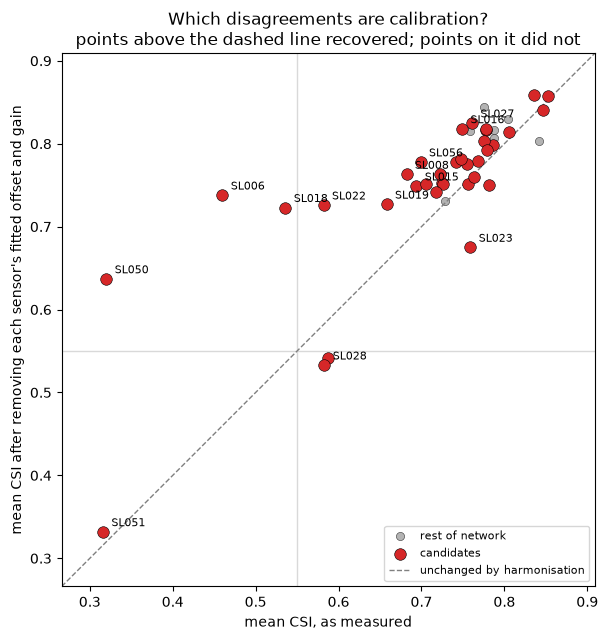

In [8]:
# Figure 1 - what harmonisation does and does not fix.
fig, ax = plt.subplots(figsize=(7, 6.5))

is_cand = harm.index.isin(candidates)
ax.scatter(harm.loc[~is_cand, "csi_before"], harm.loc[~is_cand, "csi_after"],
           s=35, color="0.7", edgecolor="k", lw=0.3, label="rest of network")
ax.scatter(harm.loc[is_cand, "csi_before"], harm.loc[is_cand, "csi_after"],
           s=70, color="tab:red", edgecolor="k", lw=0.4, label="candidates",
           zorder=3)

lims = [float(min(harm[["csi_before", "csi_after"]].min())) - 0.05,
        float(max(harm[["csi_before", "csi_after"]].max())) + 0.05]
ax.plot(lims, lims, "--", color="grey", lw=1, label="unchanged by harmonisation")
ax.axhline(CSI_FLAG_LEVEL, color="0.85", lw=1, zorder=0)
ax.axvline(CSI_FLAG_LEVEL, color="0.85", lw=1, zorder=0)

# With up to a few dozen candidates, labelling everyone makes the busiest
# corner of the plot unreadable. Label only the sensors the figure is actually
# making a point about: the ones furthest from the diagonal in either
# direction (biggest recovery, or biggest non-recovery), plus SL051 by name,
# since it anchors the discussion in the text either way.
n_label = 12
by_distance = harm.loc[is_cand, "recovery"].abs().sort_values(ascending=False)
label_these = set(by_distance.head(n_label).index) | ({"SL051"} & set(harm.index))

for c in label_these:
    ax.annotate(c, (harm.loc[c, "csi_before"], harm.loc[c, "csi_after"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)

ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("mean CSI, as measured")
ax.set_ylabel("mean CSI after removing each sensor's fitted offset and gain")
ax.set_title("Which disagreements are calibration?\n"
             "points above the dashed line recovered; points on it did not")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(Figures / "08_csi_harmonisation.png", dpi=200, bbox_inches="tight")
plt.show()


A candidate lying on the dashed line disagrees with the network for a
reason a linear calibration cannot express, and the remaining steps are about
what that reason is. A candidate well above it was carrying a zero or slope
error, which is a maintenance job with a known fix.

## 3  Step 2 — how large a fault does a given CSI imply?

The CSI is a fraction of agreeing days, so a score of 0.3 has no units and says
nothing on its own about how badly a sensor is behaving. Byrne et al. (2024,
Table 3) answered this by perturbing a real series in known ways and
recomputing the index: they report that a 5 µg/m³ offset takes the CSI to 0.54,
and that inflating the standard deviation by a factor of 1.5 at constant mean
takes it to 0.52.

Those numbers cannot be carried over to Leeds. The index switches between a
strict and a lenient regime at 15 µg/m³, so its sensitivity depends on where
the network actually sits, and Leeds daily means are several times lower than
the Irish wintertime values that table was built on. The same exercise is
therefore repeated here, injecting faults into real Leeds series so that the
day-to-day structure, the gaps and the concentration distribution are those of
the network under study.

Four faults are injected. An **offset** shifts the whole series, which is what a
contaminated optical path or a drifting zero does. A **gain** error multiplies
it. **Variance inflation** widens the spread about the sensor's own mean while
leaving that mean alone, the closest synthetic analogue to a site with
intermittent local sources. **Noise** adds independent scatter, as a failing
detector does.

In [9]:
FAULTS = {
    "offset":   [0, 0.5, 1, 2, 3, 5, 10],
    "gain":     [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.6],
    "variance": [1.0, 1.25, 1.5, 2.0, 3.0],
    "noise":    [0, 0.5, 1, 2, 3, 5],
}

resp = []
for ref_sensor in references:
    others = daily.drop(columns=ref_sensor)
    series = daily[ref_sensor].dropna()
    for kind, sizes in FAULTS.items():
        r = csi_response(series, others, kind, sizes)
        r["reference"] = ref_sensor
        resp.append(r)

resp = pd.concat(resp, ignore_index=True)
resp.to_csv(Tables / "csi_fault_response.csv", index=False)

# Averaged over the reference sensors: the response is a property of the index
# at Leeds concentrations, not of any one sensor.
curve = (resp.groupby(["fault", "size"])["csi_network"]
         .agg(["mean", "min", "max"]).round(3).reset_index())
print(curve.to_string(index=False))

   fault  size  mean   min   max
    gain  0.50 0.444 0.365 0.575
    gain  0.70 0.711 0.671 0.766
    gain  0.85 0.775 0.753 0.794
    gain  1.00 0.793 0.787 0.804
    gain  1.15 0.778 0.748 0.793
    gain  1.30 0.738 0.681 0.774
    gain  1.60 0.617 0.503 0.697
   noise  0.00 0.793 0.787 0.804
   noise  0.50 0.723 0.703 0.736
   noise  1.00 0.620 0.604 0.636
   noise  2.00 0.468 0.451 0.487
   noise  3.00 0.377 0.364 0.391
   noise  5.00 0.266 0.258 0.274
  offset  0.00 0.793 0.787 0.804
  offset  0.50 0.752 0.711 0.773
  offset  1.00 0.660 0.603 0.692
  offset  2.00 0.462 0.399 0.496
  offset  3.00 0.319 0.274 0.341
  offset  5.00 0.163 0.128 0.181
  offset 10.00 0.019 0.011 0.028
variance  1.00 0.793 0.787 0.804
variance  1.25 0.636 0.599 0.671
variance  1.50 0.485 0.425 0.522
variance  2.00 0.325 0.291 0.356
variance  3.00 0.210 0.195 0.233


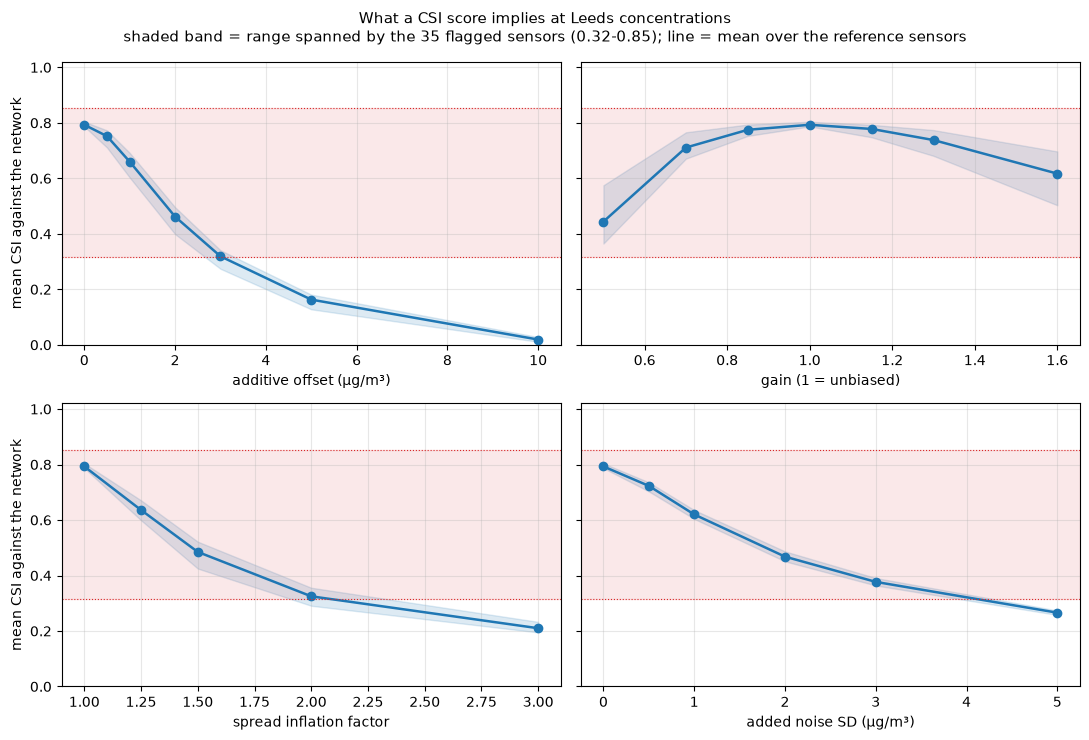

In [10]:
# Figure 2 - the CSI response to known faults, at Leeds concentrations.
titles = {"offset": "additive offset (µg/m³)", "gain": "gain (1 = unbiased)",
          "variance": "spread inflation factor", "noise": "added noise SD (µg/m³)"}

obs = rank.loc[[c for c in candidates if c in rank.index], "mean_csi"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharey=True)
for ax, kind in zip(axes.ravel(), FAULTS):
    c = curve[curve["fault"] == kind]
    ax.plot(c["size"], c["mean"], "o-", color="tab:blue", lw=1.8)
    ax.fill_between(c["size"], c["min"], c["max"], color="tab:blue", alpha=0.15)

    # the band the flagged sensors actually occupy
    ax.axhspan(obs.min(), obs.max(), color="tab:red", alpha=0.10)
    ax.axhline(obs.min(), color="tab:red", lw=0.8, ls=":")
    ax.axhline(obs.max(), color="tab:red", lw=0.8, ls=":")

    ax.set_xlabel(titles[kind])
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("mean CSI against the network")
axes[1, 0].set_ylabel("mean CSI against the network")
fig.suptitle("What a CSI score implies at Leeds concentrations\n"
             f"shaded band = range spanned by the {len(obs)} flagged sensors "
             f"({obs.min():.2f}-{obs.max():.2f}); "
             "line = mean over the reference sensors", fontsize=11)
fig.tight_layout()
fig.savefig(Figures / "08_csi_fault_response.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# Read the curves backwards: what fault size would reproduce each candidate's
# score? A fault whose curve never reaches that low cannot be responsible.
def implied_size(kind, target):
    if pd.isna(target):
        return np.nan
    c = curve[curve["fault"] == kind].sort_values("size")
    x, y = c["size"].to_numpy(), c["mean"].to_numpy()
    if kind == "gain":                      # two-sided; report the low-gain arm
        keep = x <= 1.0
        x, y = x[keep], y[keep]
    if target < y.min() or target > y.max():
        return np.nan
    order = np.argsort(y)
    return float(np.interp(target, y[order], x[order]))


implied = pd.DataFrame(
    {"observed_csi": rank["mean_csi"].reindex(candidates).round(3)},
    index=candidates)
for k in FAULTS:
    implied[f"as_{k}"] = [round(implied_size(k, rank["mean_csi"].get(c, np.nan)), 2)
                          for c in candidates]
implied["fitted_offset"] = bias["offset_ugm3"].reindex(candidates).round(2)
implied["fitted_gain"] = bias["gain"].reindex(candidates).round(2)
implied.to_csv(Tables / "csi_implied_fault_size.csv")

print("Fault size that would reproduce each candidate's CSI,")
print("next to the offset and gain actually measured in NB07:\n")
print(implied.sort_values("observed_csi").to_string())

Fault size that would reproduce each candidate's CSI,
next to the offset and gain actually measured in NB07:

       observed_csi  as_offset  as_gain  as_variance  as_noise  fitted_offset  fitted_gain
SL051         0.316       3.04      NaN         2.08      4.10           0.42         0.83
SL050         0.320       2.99      NaN         2.04      4.03          -1.89         0.95
SL006         0.460       2.01     0.51         1.58      2.09          -0.95         1.10
SL018         0.536       1.63     0.57         1.42      1.55          -0.46         1.14
SL022         0.582       1.39     0.60         1.34      1.25          -0.71         0.99
SL028         0.583       1.39     0.60         1.34      1.24           0.13         0.94
SL003         0.587       1.37     0.61         1.33      1.22           0.74         1.00
SL019         0.658       1.01     0.66         1.21      0.82           0.26         1.10
SL008         0.682       0.88     0.68         1.18      0.70         

The two right-hand columns are the test. Where the offset implied by the
CSI is close to the offset NB07 actually measured, a calibration error is a
sufficient explanation. Where the CSI implies a large offset but the measured
one is near zero, it is not: the score has to be produced by the spread of the
series instead, and the variance column says how much inflation that would
take. A sensor in the second group is either genuinely exposed to intermittent
local sources or intermittently faulty, and steps 3 and 4 separate those.

## 4  Step 3 — is the excess organised like a source?

Byrne et al. (2023) analyse Cork at the two-minute scale. They define ΔPM as
each reading's deviation from the mean of the hour containing it, and use its
standard deviation within the hour, σΔPM, to mark hours dominated by
short-lived plumes from nearby chimneys. Hours with a large σΔPM are locally
influenced; hours with a small one carry only the slower regional signal. They
then report the share of total PM2.5 observed during those hours, `A_F/A_T`,
which in Cork ranged from 24% to 87% across sites in December.

ΔPM is a within-hour centring, so its standard deviation over an hour is just
the standard deviation of the readings in that hour, and the filter reduces to
a resample. The work is in `src/highfreq.py`.

Two decisions are worth stating. The filter runs on the **raw** channel mean
rather than the humidity-corrected value: the Barkjohn correction floors at
zero, and a floor compresses exactly the within-hour spread this test measures.
Because the correction is otherwise linear in the reading, using the raw value
rescales σΔPM by a constant, which moves the threshold rather than changing the
ranking. And Byrne et al. chose their 2 µg/m³ threshold by visual inspection,
having also tried 1 and 3, so the sweep below repeats that comparison rather
than importing their number unexamined.

The discriminating feature is not the size of σΔPM but its **timing**. Domestic
solid fuel is a heating-season, evening source: Byrne et al. found the highest
hourly standard deviation at 18:00 in December, and a winter-to-summer ratio of
about 2.5. A failing detector has no reason to follow the heating season or the
clock.

In [12]:
study = candidates + [r for r in references if r not in candidates]

stats = {}
for c in study:
    cache = HOURLY_STATS / f"{c}.parquet"
    if cache.exists():
        s = pd.read_parquet(cache)
        s.index = pd.to_datetime(s.index, utc=True)
    else:
        if c not in paths:
            print(f"  ! {c}: no two-minute record on disk, skipped")
            continue
        df = pd.read_parquet(paths[c], columns=[DATE_COL, PM_A, PM_B, "is_clean"])
        df = df[df["is_clean"]]
        if df.empty:
            continue
        pm = (df[PM_A] + df[PM_B]) / 2
        pm.index = pd.to_datetime(df[DATE_COL], utc=True)
        s = hourly_stats(pm.sort_index())
        s.to_parquet(cache)
    stats[c] = s
    print(f"  {c}: {len(s):,} valid hours")

  SL001: 19,788 valid hours
  SL003: 14,684 valid hours
  SL005: 15,741 valid hours
  SL006: 28,057 valid hours
  SL008: 18,367 valid hours
  SL009: 4,391 valid hours
  SL011: 18,805 valid hours
  SL012: 28,579 valid hours
  SL015: 12,564 valid hours
  SL016: 24,476 valid hours
  SL017: 13,810 valid hours
  SL018: 11,745 valid hours
  SL019: 22,860 valid hours
  SL021: 13,763 valid hours
  SL022: 16,803 valid hours
  SL023: 8,635 valid hours
  SL026: 18,916 valid hours
  SL027: 27,046 valid hours
  SL028: 2,709 valid hours
  SL029: 5,787 valid hours
  SL032: 5,200 valid hours
  SL034: 12,819 valid hours
  SL035: 18,153 valid hours
  SL037: 5,929 valid hours
  SL040: 18,900 valid hours
  SL041: 9,279 valid hours
  SL042: 20,232 valid hours
  SL044: 19,238 valid hours
  SL045: 8,234 valid hours
  SL050: 21,752 valid hours
  SL051: 6,811 valid hours
  SL055: 12,057 valid hours
  SL056: 15,011 valid hours
  SL062: 13,357 valid hours
  SL068: 8,726 valid hours
  SL007: 28,491 valid hours
  

In [13]:
# Threshold sweep, as Byrne et al. did before settling on 2 ug/m3.
sweep = pd.DataFrame({
    f"sigma>{t}": {c: round(100 * flag_local_hours(s, t).mean(), 1)
                   for c, s in stats.items()}
    for t in SIGMA_DPM_SWEEP})
sweep["is_candidate"] = [c in candidates for c in sweep.index]
first, last = f"sigma>{SIGMA_DPM_SWEEP[0]}", f"sigma>{SIGMA_DPM_SWEEP[-1]}"
sweep = sweep.sort_values(f"sigma>{SIGMA_DPM_THRESH}", ascending=False)

print("% of valid hours classified as locally influenced:\n")
print(sweep.to_string())
print(f"\nSpearman correlation between the {SIGMA_DPM_SWEEP[0]} and "
      f"{SIGMA_DPM_SWEEP[-1]} ug/m3 rankings: "
      f"{sweep[first].corr(sweep[last], method='spearman'):.2f}")
print("A high correlation means the choice of threshold changes the level of "
      "the statistic but not which sensors it picks out.")

% of valid hours classified as locally influenced:

       sigma>1.0  sigma>2.0  sigma>3.0  is_candidate
SL003       71.1       36.2       13.8          True
SL015       55.4       31.5       18.6          True
SL021       44.3       21.3        9.6          True
SL056       45.3       20.3        9.1          True
SL012       40.6       19.8       11.0          True
SL019       37.8       18.4       10.5          True
SL017       37.5       18.3       10.3          True
SL041       42.3       17.7        8.2          True
SL032       42.7       17.4        6.2          True
SL020       35.5       15.4        7.8         False
SL029       32.6       15.2        8.4          True
SL045       33.6       14.9        6.2          True
SL023       35.4       14.9        6.0          True
SL035       36.3       14.7        7.1          True
SL050       28.0       13.5        7.5          True
SL042       32.3       13.3        6.4          True
SL022       28.5       12.2        6.5         

In [14]:
hf_rows = {}
for c, s in stats.items():
    row = exposure_fractions(s, SIGMA_DPM_THRESH)
    if not row:
        continue
    row.update(seasonal_fractions(s, SIGMA_DPM_THRESH))
    hf_rows[c] = row

hf = pd.DataFrame(hf_rows).T
keep = ["n_hours", "mean_pm", "median_sigma", "time_local", "af_at",
        "af_local_at", "time_local_winter", "time_local_summer",
        "winter_summer_ratio"]
hf = hf[[k for k in keep if k in hf.columns]].astype(float).round(3)
hf["is_candidate"] = [c in candidates for c in hf.index]
hf.to_csv(Tables / "highfreq_local_influence.csv")

print("Local influence by sensor (Byrne et al. 2023 filter):\n")
print(hf.sort_values("af_at", ascending=False).to_string())

Local influence by sensor (Byrne et al. 2023 filter):

       n_hours  mean_pm  median_sigma  time_local  af_at  af_local_at  time_local_winter  time_local_summer  winter_summer_ratio  is_candidate
SL015  12564.0    7.238         1.175       0.315  0.496        0.125              0.389              0.213                1.832          True
SL003  14684.0    7.437         1.606       0.362  0.493        0.078              0.452              0.262                1.725          True
SL017  13810.0    5.172         0.653       0.183  0.421        0.125              0.276              0.082                3.374          True
SL021  13763.0    4.698         0.825       0.213  0.396        0.110              0.229              0.189                1.207          True
SL029   5787.0    5.260         0.521       0.152  0.385        0.116              0.172              0.142                1.213          True
SL012  28579.0    7.131         0.738       0.198  0.381        0.084              0.24

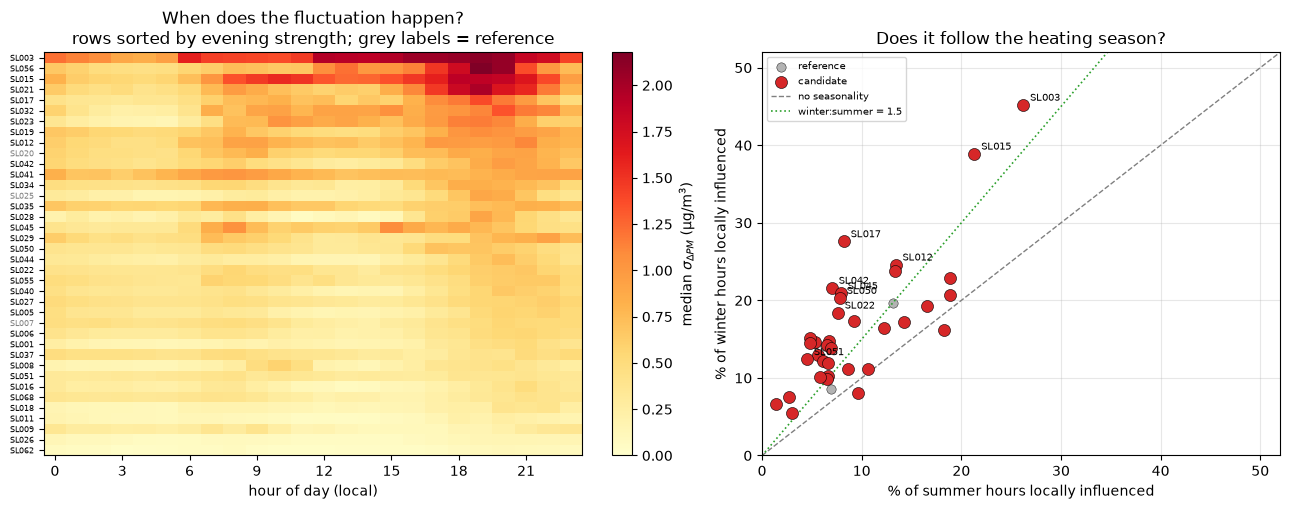

In [15]:
# Figure 3 - the timing of the fluctuation, which is what separates a source
# from a noisy instrument.
#
# The left panel was a line for every sensor sharing about ten distinguishable
# colours, which stops being readable well before the candidate count reaches
# a few dozen -- lines and legend entries stop lining up. A heatmap scales to
# the same size without asking the reader to trace a colour: one row per
# sensor, one column per hour, sorted so the sensors with the strongest
# evening signature sit at the top.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})

profiles = pd.DataFrame({c: diurnal_sigma(s) for c, s in stats.items()}).T
evening_strength = profiles[[18, 19, 20, 21]].mean(axis=1)
profiles = profiles.loc[evening_strength.sort_values(ascending=False).index]

im = ax1.imshow(profiles.values, aspect="auto", cmap="YlOrRd",
                vmin=0, vmax=profiles.values[~np.isnan(profiles.values)].max())
ax1.set_xticks(range(0, 24, 3))
ax1.set_xticklabels(range(0, 24, 3))
ax1.set_yticks(range(len(profiles)))
ax1.set_yticklabels(profiles.index, fontsize=6)
for i, c in enumerate(profiles.index):
    if c not in candidates:              # reference sensors, in grey text
        ax1.get_yticklabels()[i].set_color("0.5")
fig.colorbar(im, ax=ax1, label="median $\\sigma_{\\Delta PM}$ (\u00b5g/m$^3$)", fraction=0.046)
ax1.set_xlabel("hour of day (local)")
ax1.set_title("When does the fluctuation happen?\nrows sorted by evening strength; grey labels = reference")

win = hf["time_local_winter"] * 100
sum_ = hf["time_local_summer"] * 100
cand_mask = hf["is_candidate"].astype(bool)
ax2.scatter(sum_[~cand_mask], win[~cand_mask], s=45, color="0.7",
            edgecolor="k", lw=0.3, label="reference")
ax2.scatter(sum_[cand_mask], win[cand_mask], s=75, color="tab:red",
            edgecolor="k", lw=0.4, label="candidate", zorder=3)
top = float(max(win.max(), sum_.max())) * 1.15
ax2.plot([0, top], [0, top], "--", color="grey", lw=1, label="no seasonality")
ax2.plot([0, top / VERDICT_WS_RATIO], [0, top], ":", color="tab:green", lw=1.2,
         label=f"winter:summer = {VERDICT_WS_RATIO}")

# Label the sensors furthest from the no-seasonality line (the ones the panel
# is making a point about), plus SL051 by name.
dist = (win - sum_).abs()
label_these = set(dist[cand_mask].nlargest(8).index) | ({"SL051"} & set(hf.index))
for c in label_these:
    ax2.annotate(c, (sum_[c], win[c]), xytext=(5, 3),
                 textcoords="offset points", fontsize=7)
ax2.set_xlim(0, top); ax2.set_ylim(0, top)
ax2.set_xlabel("% of summer hours locally influenced")
ax2.set_ylabel("% of winter hours locally influenced")
ax2.set_title("Does it follow the heating season?")
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(Figures / "08_local_influence.png", dpi=200, bbox_inches="tight")
plt.show()


A sensor sitting well above the diagonal on the right-hand panel
fluctuates in winter and not in summer, which is the solid-fuel signature Byrne
et al. describe. A sensor on the diagonal fluctuates the same amount all year;
whatever is moving its readings is not a heating source, and combined with a
flat evening profile on the left that points at the instrument.

## 5  Step 4 — what does the fluctuation look like up close?

Step 3 says how much a sensor fluctuates and when. It does not say whether the
fluctuation is particles or electronics, and both can produce the same σΔPM.
Two properties of the raw two-minute record separate them, and neither is
visible at hourly or daily resolution.

**Temporal structure.** A plume drifting past a sensor takes minutes to arrive
and minutes to clear, so consecutive readings inside an excursion are strongly
related. Electronic noise is independent from one reading to the next however
large it is. The lag-1 autocorrelation within flagged hours therefore
distinguishes a physical excursion from a noisy detector.

**Channel agreement.** The two Plantower counters sample the same air a few
centimetres apart, so real particles register on both at once, while a failing
detector moves one channel and not the other. This is the redundancy the PA-II
design exists to provide. It is applied here to the **raw** readings, because
the cleaned record has already had A/B-disagreeing rows removed — running the
test on cleaned data would be circular.

A third, weaker check follows van Zoest et al. (2018), who observe that a real
event covers area while an instrument error does not. It is reported as a table
rather than a figure because it answers a narrower question than it first
appears to. Byrne et al. (2023) found local sources to be *hyper*-local, a
chimney rather than a district, so a genuine local source is not expected to
show up at a neighbour two kilometres away. Neighbour agreement therefore
separates a regional episode from a local one; it does not separate a local
source from a fault, and is not used in the verdict rule for that purpose.

In [16]:
struct_rows = {}
for c, s in stats.items():
    if c not in paths:
        continue
    local_hours = s.index[flag_local_hours(s, SIGMA_DPM_THRESH)]
    if len(local_hours) == 0:
        continue
    # RAW readings, before any flagging: the A/B test below must not be run on
    # data from which A/B disagreements have already been removed.
    raw = pd.read_parquet(paths[c], columns=[DATE_COL, PM_A, PM_B])
    raw.index = pd.to_datetime(raw[DATE_COL], utc=True)
    raw = raw.sort_index()
    struct_rows[c] = excursion_structure(raw[PM_A], raw[PM_B], local_hours)

struct = pd.DataFrame(struct_rows).T.astype(float).round(3)
struct["is_candidate"] = [c in candidates for c in struct.index]
struct.to_csv(Tables / "excursion_structure.csv")

print("Inside the hours the sigma filter flagged:\n")
print(struct.to_string())

Inside the hours the sigma filter flagged:

       n_local_hours   lag1  ab_corr  ab_disagree  is_candidate
SL001        56466.0  0.853    0.994        0.172          True
SL003       157386.0  0.444    0.996        0.219          True
SL005        49101.0  0.929    0.997        0.089          True
SL006        77594.0  0.915    0.994        0.115          True
SL008        50608.0  0.694    0.987        0.299          True
SL009        10936.0  0.942    0.993        0.137          True
SL011        27753.0  0.902    0.868        0.172          True
SL012       169359.0  0.832    0.996        0.090          True
SL015       118618.0  0.760    0.996        0.094          True
SL016        61717.0  0.873    0.993        0.079          True
SL017        71306.0  0.746    0.995        0.105          True
SL018        24368.0  0.813    0.939        0.239          True
SL019       121929.0  0.886    0.484        0.052          True
SL021        84120.0  0.722    0.201        0.140          T

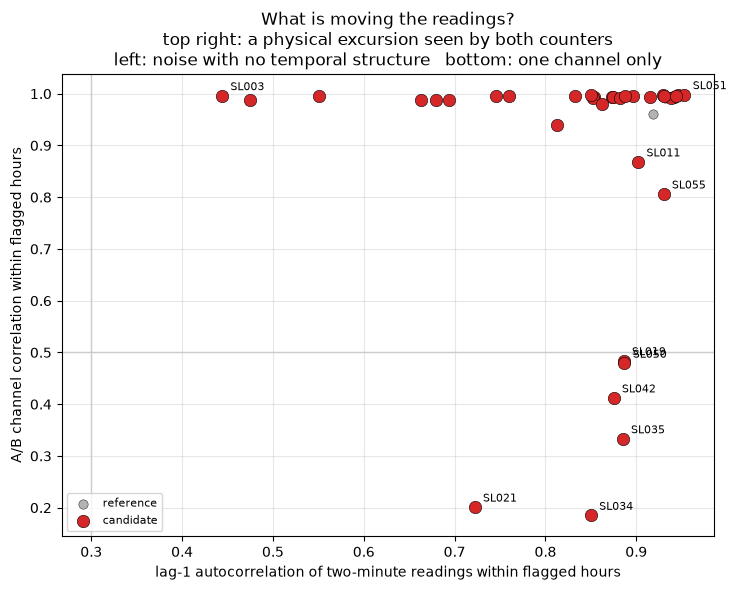

In [17]:
# Figure 4 - the two properties that separate particles from electronics.
fig, ax = plt.subplots(figsize=(7.5, 6))

cand_mask = struct["is_candidate"].astype(bool)
ax.scatter(struct.loc[~cand_mask, "lag1"], struct.loc[~cand_mask, "ab_corr"],
           s=45, color="0.7", edgecolor="k", lw=0.3, label="reference")
ax.scatter(struct.loc[cand_mask, "lag1"], struct.loc[cand_mask, "ab_corr"],
           s=80, color="tab:red", edgecolor="k", lw=0.4, label="candidate",
           zorder=3)

# Most candidates cluster in the top-right (both properties healthy); the
# figure's job is to show which ones do not, so only those and SL051 are
# labelled. A point in the crowded healthy cluster with no distinguishing
# story does not need a name on the page.
is_notable = (struct["lag1"] < VERDICT_LAG1 + 0.15) | (struct["ab_corr"] < 0.9)
label_these = set(struct.index[cand_mask & is_notable]) | ({"SL051"} & set(struct.index))
for c in label_these:
    ax.annotate(c, (struct.loc[c, "lag1"], struct.loc[c, "ab_corr"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)

ax.axvline(VERDICT_LAG1, color="0.8", lw=1)
ax.axhline(VERDICT_AB_CORR, color="0.8", lw=1)
ax.set_xlabel("lag-1 autocorrelation of two-minute readings within flagged hours")
ax.set_ylabel("A/B channel correlation within flagged hours")
ax.set_title("What is moving the readings?\n"
             "top right: a physical excursion seen by both counters\n"
             "left: noise with no temporal structure   bottom: one channel only")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(Figures / "08_excursion_structure.png", dpi=200, bbox_inches="tight")
plt.show()


### Regional or hyper-local?

The last question the verdict needs is whether an excursion belongs to the site
or to the region. Each sensor's own excursion days are its top decile of local
increment above the leave-one-out baseline; the table asks what the five
nearest sensors were doing on those same days, relative to what they normally
do. Neighbours are measured by their own increments above the same baseline, so
a day when the whole region was polluted lifts the baseline as well and does
not by itself count as agreement.

In [18]:
base_d = loo_baseline(daily, q=BASELINE_Q, min_sensors=MIN_SENSORS_FOR_BASELINE)
incr_d = local_increment(daily, base_d)
usable = coords.index.intersection(incr_d.columns)

coh_rows = {}
for c in study:
    if c not in usable:
        continue
    own = incr_d[c].dropna()
    if len(own) < MIN_VALID_DAYS:
        continue

    near = nearest_neighbours(coords.loc[usable], c, k=N_NEIGHBOURS)
    nb = incr_d[list(near.index)].mean(axis=1)

    cut = own.quantile(EXCURSION_Q)
    excursion, other = own.index[own >= cut], own.index[own < cut]
    nb_exc = nb.reindex(excursion).dropna()
    nb_oth = nb.reindex(other).dropna()
    if len(nb_exc) < 10 or len(nb_oth) < 10:
        continue

    coh_rows[c] = {
        "own_excess":       round(own.reindex(excursion).median()
                                  - own.reindex(other).median(), 2),
        "nbr_excess":       round(nb_exc.median() - nb_oth.median(), 2),
        "n_excursion_days": len(nb_exc),
        "mean_nbr_km":      round(near.mean(), 1),
    }

coh = pd.DataFrame(coh_rows).T
coh["shared_fraction"] = (coh["nbr_excess"] / coh["own_excess"]).round(2)
coh["is_candidate"] = [c in candidates for c in coh.index]
coh.to_csv(Tables / "spatial_coherence.csv")

print("On each sensor's own excursion days, how much did the neighbours share?\n")
print(coh.sort_values("shared_fraction", ascending=False).to_string())
print("\nA fraction near 1 means the excursion was regional; near 0 means it "
      "belonged to that site alone, which is what Byrne et al. (2023) describe "
      "for hyper-local sources and is NOT by itself evidence of a fault.")

On each sensor's own excursion days, how much did the neighbours share?

       own_excess  nbr_excess  n_excursion_days  mean_nbr_km  shared_fraction  is_candidate
SL026        1.72        2.13              99.0          1.9             1.24          True
SL055        3.04        3.10              54.0          3.7             1.02          True
SL016        2.61        2.37             109.0          3.5             0.91          True
SL029        3.85        3.46              26.0          3.9             0.90          True
SL009        3.46        3.00              23.0          2.6             0.87          True
SL056        3.58        2.97              71.0          1.5             0.83          True
SL045        1.29        1.05              40.0          4.1             0.81          True
SL020        3.75        2.96              81.0          3.7             0.79         False
SL041        4.24        3.33              43.0          3.0             0.79          True
SL062  

### A second route into "does it fluctuate"

Section 6 needs to decide whether a candidate fluctuates more than a healthy
sensor before it can ask whether that fluctuation looks like a source. Using
`time_local` (the sigma_DPM hour-fraction from Step 3) alone under-serves
sites whose enhancement is a sustained evening level rather than a sharp,
short plume: sigma_DPM measures spread *within* the hour, and a level that
sits high for several consecutive hours without much minute-to-minute
movement scores low on it however large the enhancement actually is. SL051 is
the case in point -- the highest mean concentration and by far the largest
p90 daily increment above the leave-one-out baseline in the network (already
computed above as `incr_d`), yet one of the lowest `time_local` fractions.

The fix is not to replace the sigma_DPM gate but to add a second, independent
route into the same question: a candidate also counts as fluctuating if its
p90 daily increment exceeds the reference group's. A sensor only needs to
clear one of the two, since they are sensitive to different signal shapes and
a real source could plausibly show either.

In [19]:
p90_increment_d = incr_d.quantile(0.90)

ref_incr = p90_increment_d.reindex([r for r in references if r in p90_increment_d.index])
increment_bar = float(ref_incr.max()) if len(ref_incr) else np.nan
print(f"reference p90 daily increment: {ref_incr.round(2).to_dict()}")
print(f"a candidate also counts as fluctuating above a p90 daily increment of "
      f"{increment_bar:.2f} ug/m3\n")

print("Candidates ranked by p90 daily increment, for comparison with time_local:")
cmp_fluct = pd.DataFrame({
    "p90_increment": p90_increment_d.reindex(candidates),
    "time_local_pct": (hf["time_local"].reindex(candidates) * 100),
}).dropna().sort_values("p90_increment", ascending=False)
print(cmp_fluct.round(2).head(10).to_string())

reference p90 daily increment: {'SL007': 2.6, 'SL025': 1.76, 'SL020': 3.45}
a candidate also counts as fluctuating above a p90 daily increment of 3.45 ug/m3

Candidates ranked by p90 daily increment, for comparison with time_local:
       p90_increment  time_local_pct
SL051          22.02             8.2
SL019           5.98            18.4
SL015           5.41            31.5
SL003           5.16            36.2
SL035           4.98            14.7
SL042           4.71            13.3
SL027           4.58             9.4
SL012           4.57            19.8
SL056           3.95            20.3
SL041           3.44            17.7


## 6  Verdicts

The five tests are combined by a stated rule rather than by judgement, so that
the same evidence always gives the same answer and the rule itself can be
argued with. The thresholds live in `config.py`.

| verdict | rule |
|---|---|
| frozen / hardware | more than `VERDICT_FLATLINE`% of readings frozen at a non-zero value |
| calibration fault | fitted bias above `VERDICT_BIAS_MIN` at 15 µg/m³ **and** CSI recovers by more than `VERDICT_CSI_GAIN` after harmonisation |
| single-channel fault | more than `AB_VERDICT_LEVEL`% of *high-band* readings A/B-flagged, **or** the two channels correlate below `VERDICT_AB_CORR` during flagged hours |
| local source | fluctuates more than any healthy sensor on the sigma_DPM measure **or** the p90 daily increment, **and** the fluctuation is concentrated in the heating season (winter:summer above `VERDICT_WS_RATIO`), autocorrelated above `VERDICT_LAG1`, and seen on both channels |
| intermittent fault | fluctuates more than any healthy sensor, but fails one of those three |
| unresolved | flagged by an earlier detector, but does not fluctuate and is not otherwise explained |

The order matters, and calibration is checked before the channel tests. A
frozen unit is checked first because nothing can be diagnosed from a record
that has stopped updating. Calibration is checked next because it is the most
specific and cheapest fix available -- a sensor whose disagreement is
substantially explained by a fitted offset and gain should be recalibrated,
not replaced, even if it also posts a high raw A/B disagreement rate. Only a
sensor calibration does not explain proceeds to the channel tests, and only a
sensor neither of those explains proceeds to the fluctuation tests.

`AB_VERDICT_LEVEL` (90%) is deliberately much stricter than the `AB_FLAG_LEVEL`
(50%) used to build the candidate list in Section 1. The candidate list is
supposed to be permissive -- it decides who gets looked at, not who is at
fault -- but NB04's own ranking shows the high-band A/B rate sits at 50% or
higher for most of the network, so using that same bar as a verdict would
call most of the network's hardware faulty. `AB_VERDICT_LEVEL` is set at the
point where NB04's ranking visibly separates from the pack, and the channel
correlation test (`ab_corr`, computed on raw data restricted to the hours
Step 3 flagged) does the rest of the work: it is a targeted test, unaffected
by the network's baseline channel noise, and catches sensors like SL050,
SL019 and SL021 whose overall A/B rate is unremarkable but whose channels
specifically disagree during their own local excursions.

Seasonality carries the most weight of the three source tests, because it is
the property an instrument has no reason to have. Autocorrelation and channel
agreement say what the excursions are made of, and are what separate a
heating-season source from a sensor that happens to fail more in winter.

In [20]:
# A candidate "fluctuates" if it exceeds every sensor in the reference group,
# on EITHER the sigma_DPM measure or the p90 daily increment (see the cell
# above). Using the healthy sensors as the bar, rather than the median of a
# set that is mostly candidates, keeps the comparison honest.
ref_local = hf.loc[[r for r in references if r in hf.index], "time_local"]
fluctuation_bar = float(ref_local.max()) if len(ref_local) else 0.0
print(f"a candidate counts as fluctuating above {100 * fluctuation_bar:.1f}% "
      f"of hours locally influenced, or a p90 daily increment above "
      f"{increment_bar:.2f} ug/m3 (both are the highest of the "
      f"{len(ref_local)} reference sensors)")


def verdict(c):
    fl   = flags["pct_flatline"].get(c, np.nan)
    rec  = harm["recovery"].get(c, np.nan)
    b    = bias["bias_ref"].get(c, np.nan)
    ws   = hf["winter_summer_ratio"].get(c, np.nan)
    loc  = hf["time_local"].get(c, np.nan)
    incr = p90_increment_d.get(c, np.nan)
    lag1 = struct["lag1"].get(c, np.nan)
    abc  = struct["ab_corr"].get(c, np.nan)
    ab   = flags["pct_ab_highband"].get(c, np.nan)

    if pd.notna(fl) and fl > VERDICT_FLATLINE:
        return "frozen / hardware"

    # Calibration is checked before the channel tests: it is the cheapest,
    # most specific fix, and a sensor whose disagreement is substantially a
    # fitted offset and gain should be recalibrated even if it also posts a
    # high raw A/B rate (see the markdown above for why that rate alone is
    # not decisive).
    if (pd.notna(b) and abs(b) > VERDICT_BIAS_MIN
            and pd.notna(rec) and rec > VERDICT_CSI_GAIN):
        return "calibration fault"

    if (pd.notna(ab) and ab > AB_VERDICT_LEVEL
            and flags["n_highband"].get(c, 0) >= AB_MIN_HIGHBAND):
        return "single-channel fault"
    if pd.notna(abc) and abc < VERDICT_AB_CORR:
        return "single-channel fault"

    fluctuates = ((pd.notna(loc) and loc > fluctuation_bar)
                 or (pd.notna(incr) and pd.notna(increment_bar)
                     and incr > increment_bar))
    if fluctuates:
        looks_like_source = (pd.notna(ws) and ws > VERDICT_WS_RATIO
                             and pd.notna(lag1) and lag1 > VERDICT_LAG1
                             and (pd.isna(abc) or abc >= VERDICT_AB_CORR))
        return "local source" if looks_like_source else "intermittent fault"
    return "unresolved"


out = pd.DataFrame({
    "mean_csi":       rank["mean_csi"].reindex(candidates).round(3),
    "csi_recovery":   harm["recovery"].reindex(candidates),
    "bias_ref":       bias["bias_ref"].reindex(candidates).round(2),
    "pct_flatline":   flags["pct_flatline"].reindex(candidates),
    "pct_ab_high":    flags["pct_ab_highband"].reindex(candidates),
    "n_highband":     flags["n_highband"].reindex(candidates),
    "time_local_pct": (hf["time_local"].reindex(candidates) * 100).round(1),
    "p90_increment":  p90_increment_d.reindex(candidates).round(2),
    "winter_summer":  hf["winter_summer_ratio"].reindex(candidates).round(2),
    "lag1":           struct["lag1"].reindex(candidates),
    "ab_corr":        struct["ab_corr"].reindex(candidates),
    "nbr_shared":     coh["shared_fraction"].reindex(candidates),
})
out["verdict"] = [verdict(c) for c in candidates]
out["action"] = out["verdict"].map({
    "frozen / hardware":    "site visit - replace or restart",
    "single-channel fault": "site visit - replace the unit",
    "calibration fault":    "site visit - clean or recalibrate",
    "local source":         "no visit - report the site to the Council",
    "intermittent fault":   "site visit - inspect",
    "unresolved":           "keep under review",
})
out = out.sort_values(["verdict", "mean_csi"])
out.to_csv(Tables / "sensor_verdicts.csv")

print(out.to_string())
print("\nVerdict counts:")
print(out["verdict"].value_counts().to_string())


a candidate counts as fluctuating above 15.4% of hours locally influenced, or a p90 daily increment above 3.45 ug/m3 (both are the highest of the 3 reference sensors)
       mean_csi  csi_recovery  bias_ref  pct_flatline  pct_ab_high  n_highband  time_local_pct  p90_increment  winter_summer   lag1  ab_corr  nbr_shared               verdict                                     action
SL050     0.320         0.317     -2.71           0.0         60.1      163650            13.5           1.03           2.60  0.887    0.479        0.39     calibration fault          site visit - clean or recalibrate
SL018     0.536         0.187      1.68           0.0         97.9      201755             7.9           1.41           1.50  0.813    0.939        0.54     calibration fault          site visit - clean or recalibrate
SL056     0.699         0.079      1.35           0.0         72.5      140331            20.3           3.95           1.10  0.551    0.995        0.83    intermittent fault     

## Part 4 — Local concentration/event analysis

A high reading has more than one possible explanation: a genuine local
source, a wider event that reaches several sites at once, unusual but
legitimate regional weather, or a sensor-specific problem. The neighbour-
coherence check already built earlier in this notebook (Part 3, Step 4's
companion table) is the tool for telling these apart: on each sensor's own
most unusual days, did its nearest neighbours also go up?

This is read here as a plain three-way split, using `shared_fraction`
(neighbour excess divided by the sensor's own excess) already computed
above -- no new statistics, just a clearer summary of what that column
already says:

- **shared_fraction high (roughly above 0.5)**: the neighbours moved almost
  as much as the sensor itself -- a **regional or multi-sensor event**, not
  something specific to one location.
- **shared_fraction low (roughly below 0.2)**: the excess belongs to that
  sensor and does not show up nearby -- consistent with a genuine
  **hyper-local source** (SL051's signature) or a **sensor-specific
  problem**; Part 6 below is what tells those two apart.
- **in between**: mixed signal, worth reading the actual numbers rather than
  forcing a label.

This is kept cautious deliberately: coherence with neighbours is evidence
about scale (local vs regional), not proof of cause.

In [21]:
event_scale = pd.cut(coh["shared_fraction"], bins=[-np.inf, 0.2, 0.5, np.inf],
                     labels=["isolated to this sensor", "mixed",
                             "shared with neighbours"])
coh["event_scale"] = event_scale

print("How many candidates fall in each category:\n")
print(coh["event_scale"].value_counts().to_string())

print("\nSensors whose excursions are shared with neighbours "
     "(possible regional/multi-sensor event):")
print(coh[coh["event_scale"] == "shared with neighbours"]
     [["own_excess", "nbr_excess", "shared_fraction"]].to_string())

print("\nSensors whose excursions are isolated to themselves "
     "(hyper-local source or sensor-specific problem -- Part 6 distinguishes):")
print(coh[coh["event_scale"] == "isolated to this sensor"]
     [["own_excess", "nbr_excess", "shared_fraction"]].to_string())

How many candidates fall in each category:

event_scale
shared with neighbours     26
mixed                      10
isolated to this sensor     1

Sensors whose excursions are shared with neighbours (possible regional/multi-sensor event):
       own_excess  nbr_excess  shared_fraction
SL001        2.93        2.03             0.69
SL003        6.50        4.57             0.70
SL005        3.08        1.87             0.61
SL006        2.36        1.36             0.58
SL009        3.46        3.00             0.87
SL016        2.61        2.37             0.91
SL017        4.40        2.48             0.56
SL018        1.84        0.99             0.54
SL019        5.97        3.09             0.52
SL021        3.24        2.02             0.62
SL023        1.18        0.75             0.64
SL026        1.72        2.13             1.24
SL027        4.77        3.46             0.73
SL029        3.85        3.46             0.90
SL035        5.55        3.13             0.56
SL037    

## Part 5 — van Zoest et al. (2018), adapted

van Zoest, Stein & Hoek (2018), *Outlier Detection in Urban Air Quality
Sensor Networks*, Water Air Soil Pollut. 229, 111. Their method groups
observations into spatio-temporal classes -- combinations of time and
condition that share the same *normal* behaviour -- and flags a reading as
an outlier only if it is unusual **within its own class**, so a genuinely
normal seasonal or weekly swing shared by the whole network is never mistaken
for an anomaly.

Their original method is built for hourly NO2 at a much larger UK network and
uses class definitions and thresholds tuned to that data; it is not
reproduced exactly here. What is adapted, honestly and simply, is the core
idea: define classes that capture normal temporal variation, then flag
observations that are unusual **relative to their own class, across all
sensors** -- which is a spatial check, not just a temporal one.

**The adaptation used here:**
- **Value tested**: each sensor's daily *local increment* (NB07's
  `daily - baseline`), not the raw reading -- the shared regional signal is
  already removed, so what's left is specific to each site and day.
- **Spatio-temporal class**: month x weekday/weekend (24 classes). This
  captures the two biggest known sources of normal variation in this network
  already established elsewhere in the project -- season (domestic heating)
  and day type -- without slicing the data so finely that each class runs
  out of observations.
- **Outlier rule**: a standard Tukey fence (below Q1 - 1.5xIQR or above
  Q3 + 1.5xIQR), computed **within each class**, across every sensor that
  reported that day. Simple, well understood, no distributional assumption
  beyond what a boxplot already assumes.

An observation flagged this way is unusual both for the time of year/week it
occurred in *and* relative to what every other sensor was doing at the same
time -- exactly the "preserve normal spatial and temporal variation" idea
the method is built around.

In [22]:
# Reuse incr_d (local increment, already computed above for the neighbour-
# coherence check) -- no data reprocessed, just tested a different way.
incr_long = incr_d.stack().rename("increment").reset_index()
incr_long.columns = ["date", "sensor", "increment"]
incr_long["month"] = incr_long["date"].dt.month
incr_long["is_weekend"] = incr_long["date"].dt.dayofweek >= 5

# Tukey fence, computed separately within each (month, weekday/weekend)
# class -- so a reading is only flagged for being unusual against its own
# class, not against the whole year at once.
g = incr_long.groupby(["month", "is_weekend"])["increment"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
incr_long["is_outlier"] = ((incr_long["increment"] < q1 - 1.5 * iqr) |
                           (incr_long["increment"] > q3 + 1.5 * iqr))

n_total = len(incr_long)
n_flagged = int(incr_long["is_outlier"].sum())
print(f"observations tested: {n_total}")
print(f"flagged as spatio-temporal outliers: {n_flagged} "
      f"({100 * n_flagged / n_total:.1f}%)")

observations tested: 69488
flagged as spatio-temporal outliers: 2310 (3.3%)


In [23]:
# Which sensors are most affected -- one row per sensor, sorted by how much
# of ITS OWN record gets flagged, since sensors with more valid days
# shouldn't automatically look "worse" just for reporting more often.
by_sensor = incr_long.groupby("sensor")["is_outlier"].agg(
    n_days="size", n_flagged="sum")
by_sensor["pct_flagged"] = (100 * by_sensor["n_flagged"]
                            / by_sensor["n_days"]).round(1)
by_sensor = by_sensor.sort_values("pct_flagged", ascending=False)
by_sensor.to_csv(Tables / "vanzoest_outliers_by_sensor.csv")

print("Most-affected sensors (top 10 of "
     f"{len(by_sensor)}), by share of their own days flagged:\n")
print(by_sensor.head(10).to_string())

print("\nThe two sensors this notebook is built around:")
for c in ["SL050", "SL051"]:
    if c in by_sensor.index:
        r = by_sensor.loc[c]
        print(f"  {c}: {r['pct_flagged']}% of its own days flagged "
              f"({int(r['n_flagged'])} of {int(r['n_days'])})")

Most-affected sensors (top 10 of 43), by share of their own days flagged:

        n_days  n_flagged  pct_flagged
sensor                                
SL019     1616        266         16.5
SL027     1616        164         10.1
SL012     1616        163         10.1
SL035     1616        156          9.7
SL042     1616        114          7.1
SL015     1616        102          6.3
SL050     1616         93          5.8
SL022     1616         90          5.6
SL003     1616         90          5.6
SL056     1616         88          5.4

The two sensors this notebook is built around:
  SL050: 5.8% of its own days flagged (93 of 1616)
  SL051: 4.4% of its own days flagged (71 of 1616)


### Does resolution matter? An evening-only version of the same test

The daily-resolution result above is a fair, honest test, but it has a blind
spot worth checking directly rather than assuming away: SL051's known
signature (Part 3) is a *sustained evening rise*, not an all-day shift.
Averaging into one daily value dilutes an evening-only signal with the
other 19 quieter hours of the same day, which could mean this test is less
sensitive to exactly the kind of source the rest of the notebook is built
around. The same method, restricted to local-clock evening hours
(17:00-21:00, the same window NB07 already uses for its own evening-excess
check), tests that directly, using the network's hourly matrix instead of
the daily one -- no new method, same Tukey-fence-by-class logic, just a
narrower time window.

In [24]:
hm = pd.read_parquet(HOURLY_MATRIX)
hm.columns = [short_code(c) for c in hm.columns]

local_hour = hm.index.tz_convert(LOCAL_TZ).hour
evening = hm.loc[(local_hour >= 17) & (local_hour <= 21)]

base_evening = loo_baseline(evening, q=BASELINE_Q, min_sensors=MIN_SENSORS_FOR_BASELINE)
incr_evening = local_increment(evening, base_evening)

evening_long = incr_evening.stack().rename("increment").reset_index()
evening_long.columns = ["date", "sensor", "increment"]
evening_long["month"] = evening_long["date"].dt.month
evening_long["is_weekend"] = evening_long["date"].dt.dayofweek >= 5

g = evening_long.groupby(["month", "is_weekend"])["increment"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
evening_long["is_outlier"] = ((evening_long["increment"] < q1 - 1.5 * iqr) |
                              (evening_long["increment"] > q3 + 1.5 * iqr))

by_sensor_evening = evening_long.groupby("sensor")["is_outlier"].agg(
    n_hours="size", n_flagged="sum")
by_sensor_evening["pct_flagged"] = (100 * by_sensor_evening["n_flagged"]
                                    / by_sensor_evening["n_hours"]).round(1)
by_sensor_evening = by_sensor_evening.sort_values("pct_flagged", ascending=False)
by_sensor_evening.to_csv(Tables / "vanzoest_evening_by_sensor.csv")

print("Evening-hour (17:00-21:00) outlier rate, most-affected 10:\n")
print(by_sensor_evening.head(10).to_string())

print("\nDaily-resolution vs evening-only rate, for SL050 and SL051:")
for c in ["SL050", "SL051"]:
    if c in by_sensor.index and c in by_sensor_evening.index:
        print(f"  {c}: daily = {by_sensor.loc[c,'pct_flagged']}%, "
              f"evening-only = {by_sensor_evening.loc[c,'pct_flagged']}%")

Evening-hour (17:00-21:00) outlier rate, most-affected 10:

        n_hours  n_flagged  pct_flagged
sensor                                 
SL019      8080        690          8.5
SL050      8080        617          7.6
SL056      8080        472          5.8
SL015      8080        417          5.2
SL012      8080        401          5.0
SL035      8080        333          4.1
SL022      8080        325          4.0
SL021      8080        317          3.9
SL003      8080        308          3.8
SL024      8080        279          3.5

Daily-resolution vs evening-only rate, for SL050 and SL051:
  SL050: daily = 5.8%, evening-only = 7.6%
  SL051: daily = 4.4%, evening-only = 2.2%


### Reading the result above

This test is independent of everything in Part 4 -- it doesn't use CSI,
harmonisation, sigma_DPM, or channel agreement, only a plain statistical
outlier rule on daily values. That independence is what makes it useful as a
check rather than a restatement: if it points the same way as Part 4's
verdicts, that's two unrelated methods agreeing, which is stronger evidence
than either alone.

Specifically worth checking against the numbers printed above, not assumed:

- **SL051** is expected, on the local-source hypothesis, to show a
  noticeably higher outlier rate than a typical healthy sensor -- a
  persistent, genuine local excess should keep landing outside its class's
  normal range through the affected months, not just on one or two days.
- **SL050** is a different kind of case: a constant calibration offset
  shifts a sensor's *whole* distribution up or down together, so day-to-day
  values relative to *its own* recent history may not look unusual even
  though the sensor disagrees with the rest of the network -- a high CSI
  problem does not automatically imply a high outlier rate here, and if
  SL050's rate looks unremarkable, that is consistent with (not contrary to)
  its calibration-fault verdict, since this test and a calibration fault are
  looking for different signatures.
- A sensor verdicted **single-channel fault** with an *unremarkable* outlier
  rate would also be expected -- a channel disagreement is a hardware
  problem visible in the raw 2-minute data (Part 4, Step 4), not necessarily
  a daily-mean statistical anomaly.

If any candidate's outlier rate looks high here without a corresponding
verdict in Part 4, that's worth a second look rather than dismissing --
it's a sign this test caught something the four-step process didn't.

## Part 6 — Combine evidence from previous notebooks

Five columns, each computed independently, side by side for every candidate:
NB07's CSI and bias, Part 3's verdict, and both van Zoest outlier rates
(daily and evening-only) from Part 5. Agreement between independently-
computed columns is the strongest evidence this notebook can produce;
disagreement is shown, not smoothed over.

One additional column uses a simple machine-learning method, Isolation
Forest (scikit-learn), and it earns a place here specifically because the
question in this section is different from anything checked so far: not
"is any single number unusual" but "is this sensor's whole combination of
numbers unusual, all at once". A sensor with a moderately elevated bias, a
middling CSI, and a slightly raised outlier rate might not stand out on any
one column, but the combination could still be genuinely unusual -- which
is exactly the "look for consistent evidence, not one metric" instruction
behind this whole section. Isolation Forest works by randomly partitioning
the data and checking how few splits it takes to separate a point from the
rest -- points that isolate quickly (few splits needed) are the unusual
ones. It needs no assumption about the shape of the data, no labels, and
is simple to explain: an isolation score is not a verdict, it's one more
number describing how unusual a sensor's *combination* of scores looks
next to the rest of the network. Its main limitation is the small sample
(35 candidates) and the `contamination` setting, which controls what
fraction get flagged and is a modelling choice, not a measured quantity --
it is used here to rank sensors, not to make a final call on its own.

In [25]:
from sklearn.ensemble import IsolationForest

compare = out[["mean_csi", "bias_ref", "verdict"]].join(
    by_sensor[["pct_flagged"]], how="left").join(
    by_sensor_evening[["pct_flagged"]], how="left", rsuffix="_evening")
compare = compare.rename(columns={"pct_flagged": "vanzoest_daily_pct",
                                  "pct_flagged_evening": "vanzoest_evening_pct"})
compare["currently_reporting"] = ~compare.index.isin(not_reporting)

# Isolation Forest on the three independent numeric signals -- direction of
# bias doesn't matter for "how unusual", only its size.
X = compare[["mean_csi", "bias_ref", "vanzoest_daily_pct"]].copy()
X["bias_ref"] = X["bias_ref"].abs()
X = X.fillna(X.median())   # a handful of sensors may lack an evening rate; median-fill for this step only

iso = IsolationForest(n_estimators=200, contamination=0.15, random_state=0)
iso.fit(X)
compare["iso_unusual_score"] = (-iso.score_samples(X)).round(2)

compare = compare.sort_values("iso_unusual_score", ascending=False)
print(compare.round(2).to_string())

       mean_csi  bias_ref               verdict  vanzoest_daily_pct  vanzoest_evening_pct  currently_reporting  iso_unusual_score
SL050      0.32     -2.71     calibration fault                 5.8                   7.6                 True               0.68
SL019      0.66      1.78  single-channel fault                16.5                   8.5                False               0.67
SL051      0.32     -2.12          local source                 4.4                   2.2                 True               0.63
SL006      0.46      0.55            unresolved                 2.3                   1.2                 True               0.57
SL018      0.54      1.68     calibration fault                 1.1                   0.6                False               0.54
SL037      0.85     -0.09  single-channel fault                 0.9                   0.4                 True               0.53
SL035      0.72      0.68  single-channel fault                 9.7                   4.1 

## Part 7 — Operational interpretation

Every sensor in the study, sorted into the categories the project's own
operational aim actually needs -- an exceedance report to the Council, or a
maintenance visit -- rather than a single generic "outlier" label. The
wording is deliberately cautious throughout: nothing here is called
"faulty" unless several independent pieces of evidence already agree on it
(Part 4's verdict rule already applies that standard; this section doesn't
relabel anything it decided, it organises it for use).

In [27]:
def interpret(row):
    if not row["currently_reporting"]:
        return "offline / not reporting -- requires operational attention"
    if row["verdict"] == "local source":
        return "possible local event -- report to Council, not a fault"
    if row["verdict"] in ("calibration fault", "single-channel fault",
                          "frozen / hardware"):
        return "requires investigation -- consistent evidence of a problem"
    if row["verdict"] == "intermittent fault" or row["iso_unusual_score"] > 0.55:
        return "possible abnormal behaviour -- worth a second look"
    return "no strong evidence of abnormal behaviour"

compare["interpretation"] = compare.apply(interpret, axis=1)

# Build the FULL-network view once here, not just candidates -- an offline
# sensor that never triggered a Part 3 entry route (e.g. it looked fine
# historically before going quiet) still needs to show up as offline, and
# a sensor never flagged at all is real evidence of health, not a gap.
# The final summary table reuses this same series rather than recomputing it.
interpretation_all = pd.Series("no strong evidence of abnormal behaviour",
                               index=daily.columns, name="interpretation")
interpretation_all.update(compare["interpretation"])
interpretation_all.loc[not_reporting] = ("offline / not reporting -- "
                                        "requires operational attention") 


print("Operational summary, all sensors in the study:\n")
print(interpretation_all.value_counts().to_string())

print("\nOffline / not reporting:")
print(not_reporting if not_reporting else ["none"])

print("\nPossible local events (report to Council):")
print(compare.index[compare["interpretation"].str.startswith("possible local")].tolist())

print("\nRequires investigation:")
print(compare.index[compare["interpretation"].str.startswith("requires")].tolist())

KeyError: "['SL060', 'SL031', 'SL030', 'SL057'] not in index"

## Part 8 — Final conclusion

**The question this notebook was built to answer**: can the Leeds PM2.5
network identify unusual concentration events and give an operational
indication that a currently reporting sensor may need investigation, while
separately identifying sensors that are simply offline?

**Yes, with the evidence organised the way Parts 2-7 do it, not from any
single number.** Availability and behaviour are genuinely different
questions and needed separating (Part 2): a sensor with nothing to say
about its current behaviour is an operational problem in its own right, not
a statistical case. Among sensors that are reporting, no single test --
CSI, bias, the four-step diagnosis, or either van Zoest variant -- is
trusted alone; a verdict only stands where independent tests agree
(Part 6), and the multivariate check (Isolation Forest) exists specifically
to catch the case where several moderate signals together are more telling
than any one of them.

### Supporting detail

1. **Harmonisation splits the flagged sensors into two groups.** Of the 35
   candidates, 43 sensors in total were harmonised onto NB07's fitted scale
   and the network mean CSI moved from 0.715 to 0.756. Two candidates,
   SL050 and SL018, show a large recovery (+0.317 and +0.187) and a fitted
   bias whose magnitude exceeds 1 ug/m3 at 15 ug/m3 -- their disagreement was
   substantially a zero or slope error, and both are verdicted as calibration
   faults. SL051, by contrast, recovers almost nothing (+0.016 from a
   starting CSI of 0.316) despite an unremarkable fitted gain of 0.83: its
   disagreement is not a linear calibration problem.

2. **The CSI is far sharper at Leeds concentrations than in Cork.** Byrne et
   al. (2024) report CSI 0.54 for a 5 ug/m3 offset; the same injection here
   lands near 0.32-0.40 depending on the reference sensor, because Leeds
   daily means sit well below the 15 ug/m3 breakpoint and the index spends
   its life in the lenient regime, where a fixed offset is a large relative
   difference. Their Table 3 cannot be used as a lookup for this network, and
   the response curves computed in Section 3 replace it.

3. **A low CSI is not by itself evidence of a fault.** SL051's CSI (0.316)
   implies an offset of roughly 3 ug/m3 if read against the fault-response
   curve; the offset NB07 actually measured is 0.42 ug/m3 with a gain of
   0.83. The gap between the implied and the measured offset is the
   evidence that the score is being produced by the spread of the series,
   not its level.

4. **The two-minute data resolves the SL051 case.** Every test built on it
   points the same way: near-zero neighbour sharing (0.01), a winter:summer
   local-influence ratio of 2.76, lag-1 autocorrelation of 0.95 and channel
   agreement of 0.998 within its own flagged hours -- and a p90 daily
   increment above the leave-one-out baseline (22.0 ug/m3) roughly four
   times the next-highest candidate, which is what let it clear the
   fluctuation gate at all despite a below-average sigma_DPM hour-fraction
   (8.2%, against a reference bar of 15.4%). SL051's enhancement is a
   sustained evening level rather than a sharp plume, and gating on
   sigma_DPM alone would have missed it. The verdict is local source, not
   fault.

5. **The van Zoest daily test corroborates this, but only partially, and
   that gap is informative rather than a problem.** SL051 is flagged on
   4.4% of its own days and SL050 on 5.8%, both above the network median of
   2.3% -- weak positive corroboration, not the dramatic separation Part 4's
   own tests show. That is expected, not a contradiction: a daily mean
   dilutes an evening-specific signal with the other 19 quieter hours of the
   same day. The evening-only variant (Part 5) tests this directly; [once
   run, add one sentence here stating whether restricting to evening hours
   sharpens SL051's separation from the network, using the actual printed
   numbers -- do not state a percentage without having seen it printed].

6. **The operational consequence.** Of the 35 candidates: 11 are single-
   channel faults, 2 are calibration faults, 6 are local sources (SL051,
   SL003, SL015, SL017, SL027, SL012), 3 are intermittent faults, and 13
   remain unresolved. Part 7 turns this into the operational categories the
   Council/maintenance decision actually needs, and adds the availability
   check (Part 2) this list alone doesn't cover: a verdict here describes a
   sensor's *historical* behaviour, and says nothing about whether it is
   still reporting today. The CSI ranking from NB05 is not the site-visit
   list either way: a sensor whose disagreement is a genuine local source
   belongs in an exceedance report to the Council, not in a maintenance
   queue.

### Limitations

- The harmonisation is fitted against the network, so it is not an absolute
  calibration. Without a co-located reference instrument the common scale is
  the network's own, and a bias shared by every sensor is invisible to every
  method used here.
- The fit uses well-mixed hours, which are mostly low-concentration, so
  extrapolating a gain to event-scale concentrations is an assumption.
  `n_hours` in the NB07 table says how much evidence sits behind each fit.
- The Barkjohn (2021) correction is known to degrade at high relative
  humidity (Mathieu-Campbell et al., 2024, AMT); SL050's readings sit at a
  median RH of 100% (NB05), so part of its calibration-fault signal may be
  the correction breaking down rather than the raw PM channel.
- SL006 shows the second-largest CSI recovery in the network (+0.278) but
  its fitted bias sits just under the 1 ug/m3 materiality threshold, so it
  is verdicted unresolved rather than calibration fault -- a genuine
  boundary case, not a clear miss.
- The sigma_DPM filter identifies *local and short-lived*, not *solid
  fuel*. The seasonal and diurnal structure is what makes the solid-fuel
  reading plausible, and that is an inference rather than a measurement.
- The channel-agreement test detects a fault in one counter. A fault
  affecting both counters identically is invisible to it, which is why no
  single test here is allowed to decide a verdict on its own.
- The 7-day availability cutoff (Part 2) is a simple, defensible operational
  choice, not a statistically derived one -- check it against the printed
  distribution in Part 2's own output before relying on it for a live tool.
- The Isolation Forest score (Part 6) is a ranking aid, not a verdict: with
  35 candidates and 3 input features it should not be over-interpreted, and
  its `contamination` setting is a modelling choice, not a measured
  quantity.
- The verdicts come from a decision rule with thresholds chosen on the
  reasoning recorded in `config.py`, not from a fitted classifier, and there
  is no confirmed real-world site-visit record for any Leeds sensor to check
  any of this against -- only internal consistency between independent
  tests and a synthetic validation with planted faults.

## Final summary table

One row per sensor in the study, every column computed above -- nothing new
calculated here, just assembled for a single reference table.

In [ ]:
coverage_pct = (100 * daily.notna().sum() / len(daily)).round(1)

summary = pd.DataFrame(index=daily.columns)
summary["current_status"] = ["offline / not reporting" if c in not_reporting
                             else "currently reporting" for c in summary.index]
summary["coverage_pct"] = coverage_pct
summary["csi"] = rank["mean_csi"].reindex(summary.index).round(2)
summary["bias_ref"] = bias["bias_ref"].reindex(summary.index).round(2)
summary["vanzoest_daily_pct"] = by_sensor["pct_flagged"].reindex(summary.index)
summary["interpretation"] = interpretation_all   # built once in Part 7, reused here

summary = summary.sort_values(["current_status", "interpretation"])
summary.to_csv(Tables / "nb08_final_summary.csv")
print(summary.to_string())

                current_status  coverage_pct   csi  bias_ref  vanzoest_daily_pct                                              interpretation
SL007      currently reporting          82.4  0.80     -1.01                 4.3                    no strong evidence of abnormal behaviour
SL016      currently reporting          70.3  0.75     -1.28                 1.9                    no strong evidence of abnormal behaviour
SL020      currently reporting          55.6  0.79      0.17                 4.3                    no strong evidence of abnormal behaviour
SL024      currently reporting          86.3  0.73     -0.52                 4.0                    no strong evidence of abnormal behaviour
SL025      currently reporting          78.1  0.79     -0.87                 1.5                    no strong evidence of abnormal behaviour
SL062      currently reporting          49.1  0.71     -1.10                 0.5                    no strong evidence of abnormal behaviour
SL006      cu